In [1]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
import pandas as pd
import time

# from numpy import linalg as LA
from scipy.interpolate import griddata

In [2]:
# CUDA support 
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    
print(device)

cuda


In [3]:
torch.cuda.set_device(1)
torch.manual_seed(1234)
np.random.seed(1234)

In [4]:
start_time = time.time()

In [5]:
# checkpoint_dir = os.path.dirname(r"/home/u/reynaquita2905/weights/pinn_paper/case9_3/cp-{epoch:06d}.ckpt")
checkpoint_dir = os.path.dirname(r"/home/u/reynaquita2905/weights/model 1/cp-{epoch:06d}.ckpt")
checkpoint_path_ffm = checkpoint_dir + "/ffm/best-cp.ckpt"
checkpoint_path_ffp = checkpoint_dir + "/ffp/best-cp.ckpt"

# checkpoint_path_ffm = checkpoint_dir + "/ffm/cp-100000.ckpt"
# checkpoint_path_ffp = checkpoint_dir + "/ffp/cp-100000.ckpt"

In [6]:
number_layers_1 = 10
number_layers_2 = 8
number_neurons = 40
output_size = 1

In [7]:
def init_model(input_size, layers, output_size = output_size, layer_width = number_neurons):
    model = nn.Sequential() 
    model.add_module("dense_0", nn.Linear(input_size, layer_width))
    model.add_module("activation_0", nn.Tanh())
    
    for i in range(1, layers):
        model.add_module('dense_%d' % i, nn.Linear(layer_width, layer_width))
        model.add_module('activation_%d' % i, nn.Tanh())

    model.add_module('dense_' + str(i+1), nn.Linear(layer_width, output_size))
    model.add_module('activation_%d' % i, nn.Sigmoid())
    
    return model

In [8]:
ffm = init_model(input_size = 2, layers = number_layers_1)
ffm = ffm.to(device)
ffm.load_state_dict(torch.load(checkpoint_path_ffm))
ffm.eval()

ffp = init_model(input_size = 2, layers = number_layers_2 )
ffp = ffp.to(device)
ffp.load_state_dict(torch.load(checkpoint_path_ffp))
ffp.eval()

/tmp/ipykernel_2432796/1858453776.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ffm.load_state_dict(torch.load(checkpoint_path_ffm))
/tmp/ipykernel_2432796/1858453776.

Sequential(
  (dense_0): Linear(in_features=2, out_features=40, bias=True)
  (activation_0): Tanh()
  (dense_1): Linear(in_features=40, out_features=40, bias=True)
  (activation_1): Tanh()
  (dense_2): Linear(in_features=40, out_features=40, bias=True)
  (activation_2): Tanh()
  (dense_3): Linear(in_features=40, out_features=40, bias=True)
  (activation_3): Tanh()
  (dense_4): Linear(in_features=40, out_features=40, bias=True)
  (activation_4): Tanh()
  (dense_5): Linear(in_features=40, out_features=40, bias=True)
  (activation_5): Tanh()
  (dense_6): Linear(in_features=40, out_features=40, bias=True)
  (activation_6): Tanh()
  (dense_7): Linear(in_features=40, out_features=40, bias=True)
  (activation_7): Sigmoid()
  (dense_8): Linear(in_features=40, out_features=1, bias=True)
)

In [9]:
delta = 5e-2

a_t = 0
b_t = 0.5 #2
a_xi = - delta
b_xi = delta


number_of_grid_xi = 5000
number_of_grid_t = 1000 #1000

N  = (b_xi - a_xi)*number_of_grid_xi
Nt = (b_t - a_t)*number_of_grid_t
h_ = (b_xi - a_xi)/N
k = (b_t - a_t)/Nt

t = np.arange(a_t, b_t, k)
xi = np.arange(a_xi, b_xi, h_)
Xi, T = np.meshgrid(xi, t)

In [10]:
C_star = 0.1
eta = 1

h = lambda t, c = C_star, eta = eta : eta * t + c
h_prime = lambda t, eta = eta: np.ones(t.shape) * eta

# h = lambda t, c = C_star, eta = eta : eta * t * t + c
# h_prime = lambda t, eta = eta: 2 * eta * t



In [11]:
X_star_ = np.hstack((Xi.flatten()[:,None], T.flatten()[:,None]))

cond = X_star_[:,0:1] < 0
X_star_1 = np.where(cond, X_star_, np.nan)
X_star_1 = X_star_1[~np.isnan(X_star_1).any(axis=1)]
X_star_1_ = torch.tensor(X_star_1, requires_grad=False).float().to(device)

X_star_2 = np.where(cond, np.nan, X_star_)
X_star_2 = X_star_2[~np.isnan(X_star_2).any(axis=1)]
X_star_2_ = torch.tensor(X_star_2, requires_grad=False).float().to(device)

In [12]:
Um = ffm(X_star_1_)
Up = ffp(X_star_2_)

Um = Um.cpu().detach().numpy()
Up = Up.cpu().detach().numpy()

X_star = np.concatenate([X_star_1, X_star_2])
u_pred = np.concatenate([Um, Up])

In [13]:
U_pred = griddata(X_star, u_pred.flatten(), (Xi, T), method='cubic')


In [14]:
U_exact = np.load(checkpoint_dir + r"/U_exact.npy")
# U_exact = U_exact[,]
print(U_exact.shape)

(2500, 500)


In [15]:
# U_exact = np.load(checkpoint_dir + r"/U_exact.npy")
# U_exact = U_exact[:-1,:-2]
# print(U_exact.shape)
# U_exact_new = U_exact

In [16]:
gap = int(U_exact.shape[0] / len(t))
print(gap)

indices = np.arange(0,U_exact.shape[0],gap)
# indices = np.reshape(indices, (indices.shape[0], 1))

U_exact_new = U_exact[indices]
print(U_exact_new.shape)

5
(500, 500)


In [17]:
X = np.zeros((Xi.shape))

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        X[i,j] = Xi[i,j] + h(T[i,j])

In [18]:
ts = [0.00, 0.005, 0.1, 0.4]
# ts = [0.00025, 0.0005, 0.0015, 0.002]
# ts = [0.0025, 0.003, 0.0035, 0.004]

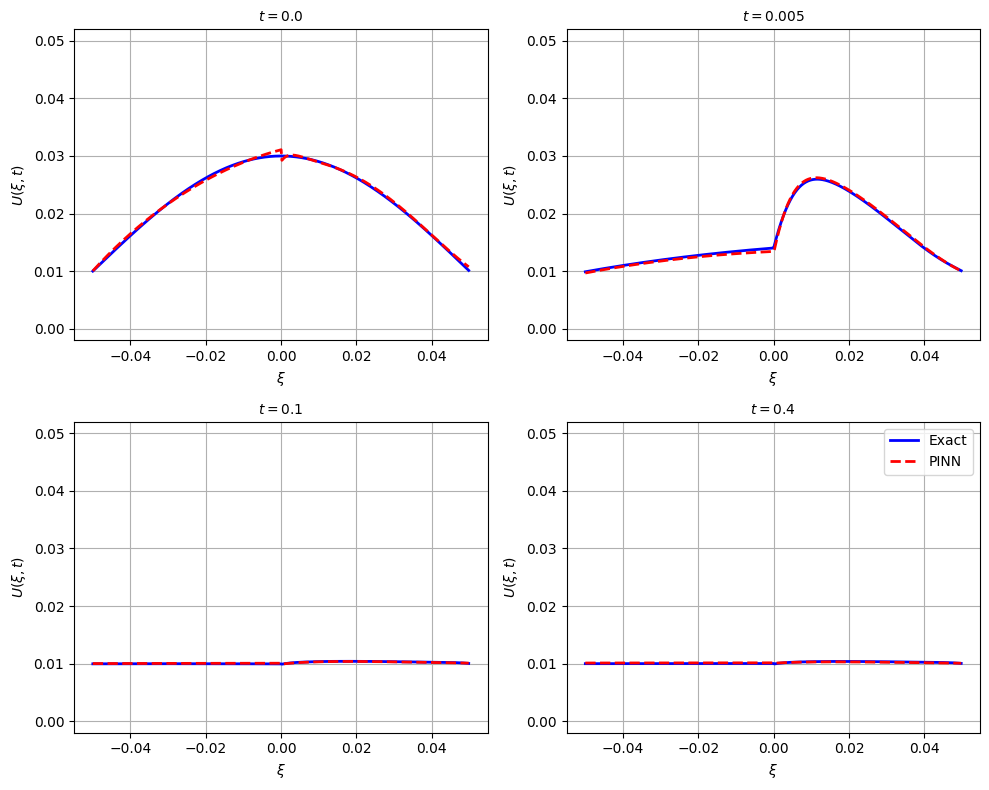

In [19]:
fig, axs = plt.subplots(2, 2,figsize=(10,8))


# axs[0, 0].plot(xi,U_exact[int((ts[0]/b_t)*U_exact.shape[0]),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[0, 0].plot(xi,U_exact_new[int((ts[0]/b_t)*(len(t)-1)),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[0, 0].plot(xi,U_pred[int((ts[0]/b_t)*(len(t)-1)),:], linewidth = 2, linestyle = '--', color = 'r', label = 'PINN')
axs[0, 0].set_title('$t = $' + str(ts[0]), fontsize = 10)
axs[0, 0].set_ylim([0. - 0.002, 0.05 + 0.002])
# axs[0, 0].set_ylim([0.95  - 0.002, 1 + 0.002])
# axs[0, 0].set_ylim([0.3  - 0.002, 0.35 + 0.002])
# axs[0, 0].set_ylim([0.7  - 0.002, 0.75 + 0.002])
axs[0, 0].grid()

# axs[0, 1].plot(xi,U_exact[int((ts[1]/b_t)*U_exact.shape[0]),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[0, 1].plot(xi,U_exact_new[int((ts[1]/b_t)*(len(t)-1)),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[0, 1].plot(xi,U_pred[int((ts[1]/b_t)*(len(t)-1)),:], linewidth = 2, linestyle = '--', color = 'r', label = 'PINN')
axs[0, 1].set_title('$t = $' + str(ts[1]), fontsize = 10)
axs[0, 1].set_ylim([0. - 0.002, 0.05 + 0.002])
# axs[0, 1].set_ylim([0.95  - 0.002, 1 + 0.002])
# axs[0, 1].set_ylim([0.3  - 0.002, 0.35 + 0.002])
# axs[0, 1].set_ylim([0.7  - 0.002, 0.75 + 0.002])
axs[0, 1].grid()

# axs[1, 0].plot(xi,U_exact[int((ts[2]/b_t)*U_exact.shape[0]),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[1, 0].plot(xi,U_exact_new[int((ts[2]/b_t)*(len(t)-1)),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[1, 0].plot(xi,U_pred[int((ts[2]/b_t)*(len(t)-1)),:], linewidth = 2, linestyle = '--', color = 'r', label = 'PINN')
axs[1, 0].set_title('$t = $'+ str(ts[2]), fontsize = 10)
axs[1, 0].set_ylim([0. - 0.002, 0.05 + 0.002])
# axs[1, 0].set_ylim([0.95  - 0.002, 1 + 0.002])
# axs[1, 0].set_ylim([0.3  - 0.002, 0.35 + 0.002])
# axs[1, 0].set_ylim([0.7  - 0.002, 0.75 + 0.002])
axs[1, 0].grid()

# axs[1, 1].plot(xi,U_exact[int((ts[3]/b_t)*U_exact.shape[0]),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[1, 1].plot(xi,U_exact_new[int((ts[3]/b_t)*(len(t)-1)),:], linewidth = 2, color = 'blue', label = 'Exact')
axs[1, 1].plot(xi,U_pred[int((ts[3]/b_t)*(len(t)-1)),:], linewidth = 2, linestyle = '--', color = 'r', label = 'PINN')
axs[1, 1].set_title('$t = $' + str(ts[3]), fontsize = 10)
axs[1, 1].set_ylim([0. - 0.002, 0.05 + 0.002])
# axs[1, 1].set_ylim([0.95  - 0.002, 1 + 0.002])
# axs[1, 1].set_ylim([0.3  - 0.002, 0.35 + 0.002])
# axs[1, 1].set_ylim([0.7  - 0.002, 0.75 + 0.002])
axs[1, 1].grid()

for ax in axs.flat:
    ax.set(xlabel=r'$\xi$', ylabel=r'$U(\xi,t)$')
    
plt.legend()
fig.tight_layout()
plt.savefig(checkpoint_dir + "/uplot_xi.pdf", format="pdf", bbox_inches="tight")
plt.savefig(checkpoint_dir + "/uplot_xi.png", bbox_inches="tight")
plt.show() 

In [32]:
error = np.absolute(U_exact_new[:-1,:] - U_pred[:-1,:])

rel_l2_norm = np.linalg.norm(error,2)/np.linalg.norm(U_exact_new[:-1,:],2)
print("Relative L2 norm: ", rel_l2_norm)

l2_norm = np.linalg.norm(error, 2) #/np.linalg.norm(U_exact_new[:-1,:],2)
print("L2 norm: ", l2_norm)

Relative L2 norm:  0.009229950762939653
L2 norm:  0.04808735223478973


In [21]:
end_time = time.time()
elapsed_time = end_time - start_time
print(elapsed_time)

with open(checkpoint_dir + "/time_test_cpinn.txt", 'w') as file:
    file.write(f"Time: {str(elapsed_time)}") 

9.32874608039856


In [ ]:
# # set up a figure twice as wide as it is tall
# fig = plt.figure(figsize=plt.figaspect(0.3))

# #===============
# #  First subplot
# #===============
# # set up the axes for the first plot
# ax = fig.add_subplot(1, 3, 1, projection='3d')
# surf = ax.plot_surface(Xi, T, U_pred, rstride=1, cstride=1,
#                 cmap='plasma', edgecolor='none')
# ax.set_title('cPINNs Solution')
# ax.set_xlabel(r'$\xi$')
# ax.set_ylabel('t')
# ax.set_zlabel(r'$U(\xi,t)$')
# ax.set_xlim(a_xi, b_xi)
# ax.set_ylim(a_t, b_t)
# ax.set_zlim(0.  - 0.002, 0.05 + 0.002)
# # ax.set_zlim(0.96  - 0.002, 1 + 0.002)

# #===============
# # Second subplot
# #===============
# # set up the axes for the second plot
# ax = fig.add_subplot(1, 3, 2, projection='3d')
# surf = ax.plot_surface(Xi, T, U_exact_new, rstride=1, cstride=1,
#                 cmap='plasma', edgecolor='none')
# ax.set_title('Approximated Solution')
# ax.set_xlabel(r'$\xi$')
# ax.set_ylabel('t')
# ax.set_zlabel(r'$U(\xi,t)$')
# ax.set_xlim(a_xi, b_xi)
# ax.set_ylim(a_t, b_t)
# ax.set_zlim(0.  - 0.002, 0.05 + 0.002)
# # ax.set_zlim(0.96  - 0.002, 1 + 0.002)

# #===============
# # Third subplot
# #===============
# # set up the axes for the third plot
# ax = fig.add_subplot(1, 3, 3, projection='3d')
# # surf = ax.plot_surface(Xi, T, error, rstride=1, cstride=1,
# #                 cmap='magma', edgecolor='none')
# surf = ax.plot_surface(Xi[:-1,:], T[:-1,:], error, cmap='cividis', edgecolor='none')
# ax.set_title('Error')
# ax.set_xlabel(r'$\xi$')
# ax.set_ylabel('t')
# ax.set_zlabel('Error')
# ax.set_xlim(a_xi, b_xi)
# ax.set_ylim(a_t, b_t)

# plt.savefig(checkpoint_dir + "/uplot_3d_xi.pdf", format="pdf", bbox_inches="tight")
# plt.savefig(checkpoint_dir + "/uplot_3d_xi.png", bbox_inches="tight")
# plt.show()

In [ ]:
# # set up a figure twice as wide as it is tall
# fig = plt.figure(figsize=plt.figaspect(0.3))

# #===============
# #  First subplot
# #===============
# # set up the axes for the first plot
# ax = fig.add_subplot(1, 3, 1, projection='3d')
# surf = ax.plot_surface(X, T, U_pred, rstride=1, cstride=1,
#                 cmap='plasma', edgecolor='none')
# ax.set_title('cPINNs Solution')
# ax.set_xlabel('x')
# ax.set_ylabel('t')
# ax.set_zlabel(r'$U(x,t)$')
# ax.set_zlim(0.  - 0.002, 0.05 + 0.002)
# # ax.set_zlim(0.96  - 0.002, 1 + 0.002)

# #===============
# # Second subplot
# #===============
# # set up the axes for the second plot
# ax = fig.add_subplot(1, 3, 2, projection='3d')
# surf = ax.plot_surface(X, T, U_exact_new, rstride=1, cstride=1,
#                 cmap='plasma', edgecolor='none')
# ax.set_title('Approximated Solution')
# ax.set_xlabel('x')
# ax.set_ylabel('t')
# ax.set_zlabel(r'$U(x,t)$')
# ax.set_zlim(0.  - 0.002, 0.05 + 0.002)
# # ax.set_zlim(0.96  - 0.002, 1 + 0.002)

# #===============
# # Third subplot
# #===============
# # set up the axes for the third plot
# ax = fig.add_subplot(1, 3, 3, projection='3d')
# surf = ax.plot_surface(X[:-1,:], T[:-1,:], error, cmap='cividis', edgecolor='none')
# ax.set_title('Error')
# ax.set_xlabel('x')
# ax.set_ylabel('t')
# ax.set_zlabel('Error')

# plt.savefig(checkpoint_dir + "/uplot_3d_x.pdf", format="pdf", bbox_inches="tight")
# plt.savefig(checkpoint_dir + "/uplot_3d_x.png", bbox_inches="tight")
# plt.show()

In [24]:
data1 = pd.read_csv(checkpoint_dir + "/loss_adam.csv")
loss_m_list1 = data1['lossm'].tolist()
loss_p_list1 = data1['lossp'].tolist()

In [25]:
loss_m_list = loss_m_list1 #+ loss_ic_list2
loss_p_list = loss_p_list1


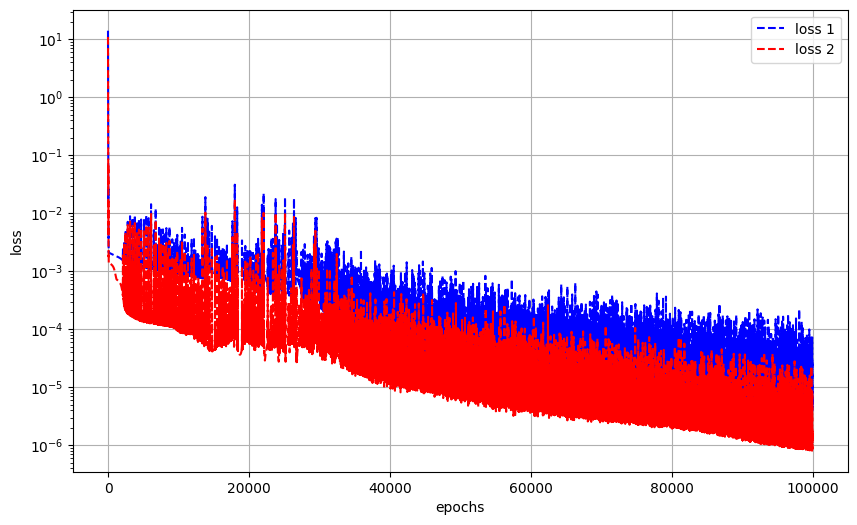

In [26]:
plt.figure(figsize=(10,6))
plt.plot(loss_m_list, linestyle = "--",color='blue', label = "loss 1" )
plt.plot(loss_p_list, linestyle = "--",color='red', label = "loss 2" )
plt.yscale('log', base=10)
plt.ylabel('loss') 
plt.xlabel('epochs')
plt.legend()
plt.grid()
plt.savefig(checkpoint_dir + "/lossplot1.pdf", format="pdf", bbox_inches="tight")
plt.savefig(checkpoint_dir + "/lossplot1.png", bbox_inches="tight")
plt.show() 

In [27]:
with open (checkpoint_dir + "/info2.txt", 'w') as file:  
    file.write("relative L2 norm: %s \n L2 norm: %s \n number of layers 1: %s \n number of layers 2: %s \n number of neurons: %s \n" % (str(rel_l2_norm), str(l2_norm), str(number_layers_1), str(number_layers_2), str(number_neurons)))

In [ ]:
np.save(checkpoint_dir + r"/U_pred.npy", U_pred)
# np.save(checkpoint_dir + r"/U_exact.npy", U_exact)